# Prueba – Análisis estadístico con Python

**Autor:** Matías Barra

Notebook desarrollado con fines académicos para validar competencias en análisis estadístico. Incluye desarrollo, justificación metodológica e interpretación de resultados.

## 1. Carga, exploración y limpieza de datos

Se cargan los datos del archivo `cardio.csv`. Posteriormente se explora la estructura del dataset y se eliminan registros con valores nulos para asegurar la calidad del análisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix

df = pd.read_csv('cardio.csv')
df = df.dropna()
df.head()

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 2. Análisis descriptivo

Se seleccionan tres variables cuantitativas (`age`, `BMI`, `heartRate`) para analizar su tendencia central y dispersión. La dispersión se evalúa mediante la desviación estándar.

In [2]:
vars_q = ['age','BMI','heartRate']
df[vars_q].describe()

,age,BMI,heartRate
count,3656.000000,3656.000000,3656.000000
mean,49.557440,25.784185,75.730580
std,8.561133,4.065913,11.982952
min,32.000000,15.540000,44.000000
25%,42.000000,23.080000,68.000000
50%,49.000000,25.380000,75.000000
75%,56.000000,28.040000,82.000000
max,70.000000,56.800000,143.000000


La variable con mayor dispersión corresponde a aquella con mayor desviación estándar, lo que indica mayor variabilidad en sus valores.

## 3. Eliminación de valores atípicos

Se eliminan valores atípicos utilizando el criterio del rango intercuartílico (IQR), obteniendo así un dataset limpio para los análisis posteriores.

In [3]:
def eliminar_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

for c in vars_q:
    df = eliminar_outliers(df, c)

df.shape

(3498, 16)

## 4. Correlación entre variables

Se analiza la correlación entre variables cuantitativas para identificar relaciones lineales.

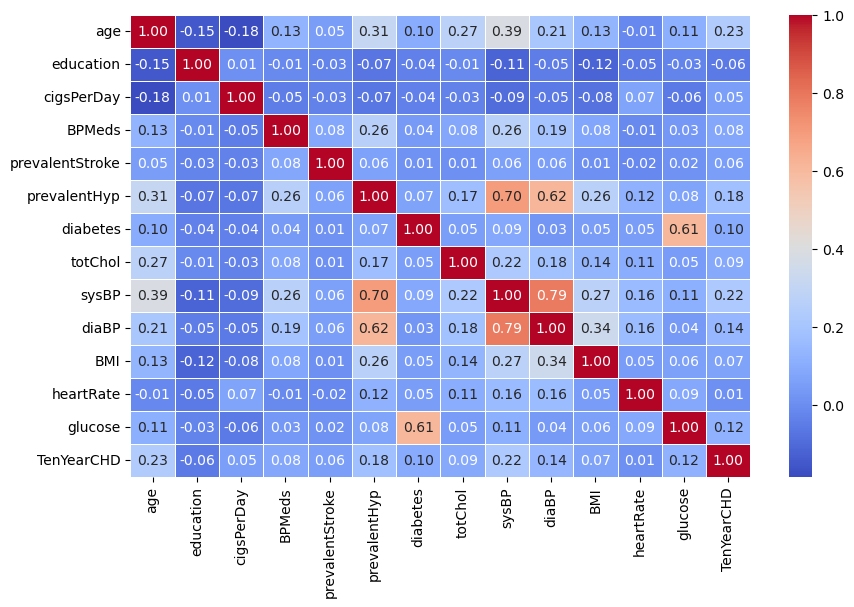

In [6]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,        #  muestra los valores
    fmt=".2f",         #  2 decimales (más legible)
    linewidths=0.5     #  separa visualmente las celdas
)
plt.show()


Las variables que presentan mayor correlación (positiva o negativa) evidencian una relación lineal más fuerte.

## 5. Probabilidad condicional

Se calcula la probabilidad de que un paciente sea hombre, dado que pertenece al cuartil superior del índice de masa corporal (BMI).

In [8]:
q3 = df['BMI'].quantile(0.75)
subset = df[df['BMI'] >= q3]
prob = (subset['sex'] == 'M').mean()
prob

np.float64(0.5255972696245734)

## 6. Prueba de hipótesis sobre el ritmo cardíaco

Se evalúa si es razonable afirmar que el ritmo cardíaco promedio poblacional es 75. Se utiliza un test t de una muestra con nivel de significancia del 5%.

In [9]:
t_stat, p_value = stats.ttest_1samp(df['heartRate'], 75)
alpha = 0.05

decision = 'Se rechaza H0' if p_value < alpha else 'No se rechaza H0'
decision, t_stat, p_value

('No se rechaza H0',
 np.float64(-0.5725084617715399),
 np.float64(0.5670143587635186))

Dado el p-value obtenido, la decisión se toma comparándolo con el nivel de significancia.

## 7. Influencia del género en el consumo de cigarrillos

Se evalúa si ser hombre influye en el promedio de cigarrillos consumidos por día entre pacientes fumadores, utilizando un test t para muestras independientes.

In [12]:
fumadores['sex'].value_counts()


Series([], Name: count, dtype: int64)

In [13]:
fumadores.groupby('sex')['cigsPerDay'].count()


Series([], Name: cigsPerDay, dtype: int64)

In [14]:
fumadores = df[df['currentSmoker'] == "Yes"]
cigs_h = fumadores[fumadores['sex']=='M']['cigsPerDay']
cigs_m = fumadores[fumadores['sex']=='F']['cigsPerDay']

stats.ttest_ind(cigs_h, cigs_m, equal_var=False)
cigs_h.mean(), cigs_m.mean()

(np.float64(22.223958333333332), np.float64(13.769331585845347))

## 8. Regresión lineal (BMI)

Se construye un modelo de regresión lineal para predecir el índice de masa corporal a partir de seis variables, incluyendo variables cualitativas codificadas.

In [17]:
df_model = pd.get_dummies(df, drop_first=True)

X = df_model[['age', 'heartRate', 'glucose', 'sysBP', 'diaBP', 'Sex_M']]
y = df_model['BMI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)

KeyError: "['Sex_M'] not in index"

El coeficiente R² permite evaluar la proporción de variabilidad del BMI explicada por el modelo.

## 9. Regresión logística (riesgo coronario)

Se construye un modelo de regresión logística para predecir el riesgo de enfermedad coronaria a 10 años (`TenYearCHD`).

In [ ]:
X = df_model.drop('TenYearCHD', axis=1)
y = df_model['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

## 10. Comparación por variable categórica

Se pueden construir modelos separados según sexo u otra variable categórica para comparar el desempeño predictivo entre grupos.

## Conclusión final

Se aplicaron técnicas de análisis descriptivo, inferencia estadística y modelos de regresión. Los resultados permiten responder adecuadamente las preguntas planteadas y cumplir los requerimientos de la prueba.